In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load cleaned data
file_path = r"C:\Users\Vanitha\OneDrive\Documents\GUVI\capstone_project\job_acceptance_prediction_system\data\cleaned\job_acceptance_cleaned.csv"
df = pd.read_csv(file_path)

df.shape
df.head()

,age_years,gender,ssc_percentage,hsc_percentage,degree_percentage,degree_specialization,technical_score,aptitude_score,communication_score,skills_match_percentage,...,expected_ctc_lpa,company_tier,job_role_match,competition_level,bond_requirement,notice_period_days,layoff_history,employment_gap_months,relocation_willingness,status
0,-0.125568,1,-0.635376,1.291098,0.931394,0,-0.827125,2.576075,-0.164746,0.475780,...,-0.769538,2,1,2,0,-0.201725,0,3.406134,0,0
1,-0.870846,1,-0.272108,-1.169454,-0.963692,1,0.329015,-0.948746,-0.507640,-0.052684,...,0.881626,0,0,0,1,-0.814382,0,-0.678800,0,0
2,1.364987,0,0.500596,-0.243202,2.051606,2,0.372630,-0.546106,1.351319,0.129682,...,-0.878147,2,1,1,0,-0.814382,0,0.002023,0,1
3,0.868135,1,0.533154,0.121118,-0.406301,3,0.913382,-0.300701,-1.248190,-0.022133,...,0.608575,1,0,1,0,-0.814382,1,0.682845,1,0
4,0.122857,1,-1.225270,-1.493163,0.395154,2,0.021871,0.172139,-0.471201,1.276681,...,0.258875,1,0,2,0,-0.814382,0,0.002023,1,0


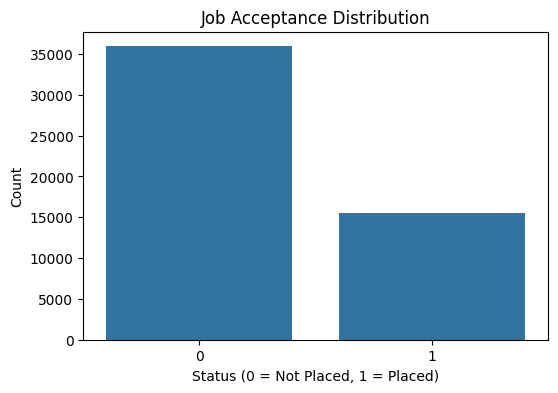

status
0    69.749515
1    30.250485
Name: proportion, dtype: float64


In [7]:
# 1. Target Variable Distribution
plt.figure(figsize=(6,4))
sns.countplot(x='status', data=df)
plt.title('Job Acceptance Distribution')
plt.xlabel('Status (0 = Not Placed, 1 = Placed)')
plt.ylabel('Count')
plt.show()

print(df['status'].value_counts(normalize=True)*100) 

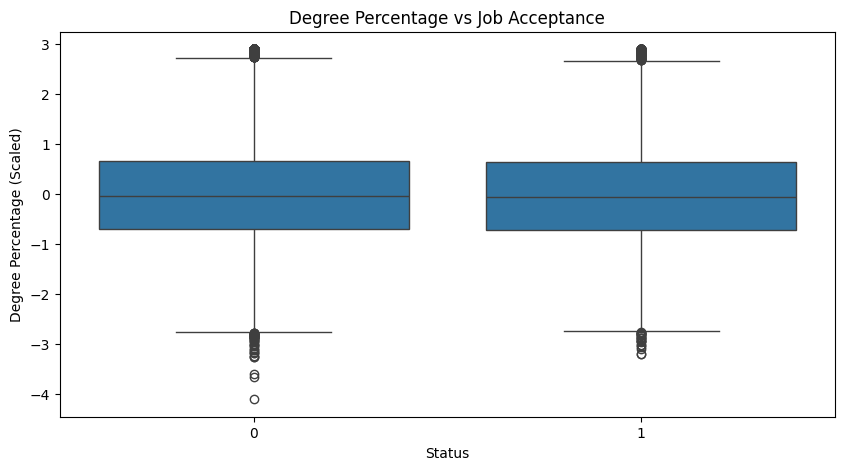

In [8]:
# 2. Academic Performance Vs Job Acceptance
plt.figure(figsize=(10,5))
sns.boxplot(x='status', y='degree_percentage', data=df)
plt.title('Degree Percentage vs Job Acceptance')
plt.xlabel('Status')
plt.ylabel('Degree Percentage (Scaled)')
plt.show() 

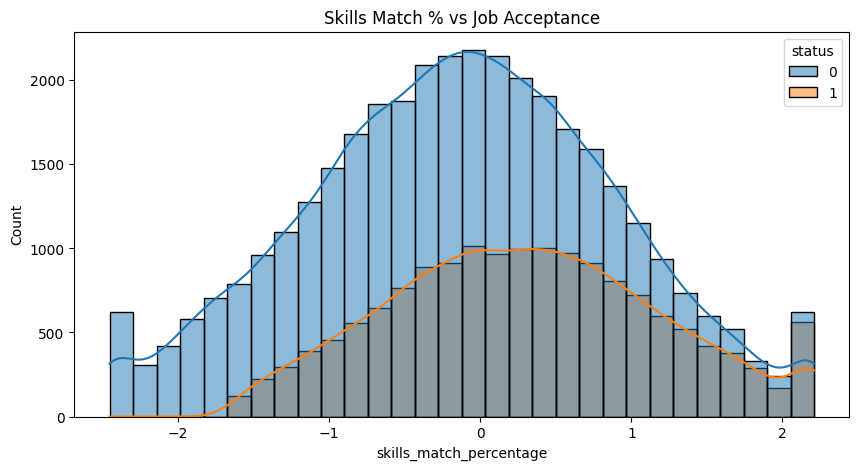

In [9]:
# 3. Skills Match % vs Job Acceptance
plt.figure(figsize=(10,5))
sns.histplot(data=df, x='skills_match_percentage', hue='status', bins=30, kde=True)
plt.title('Skills Match % vs Job Acceptance')
plt.show() 

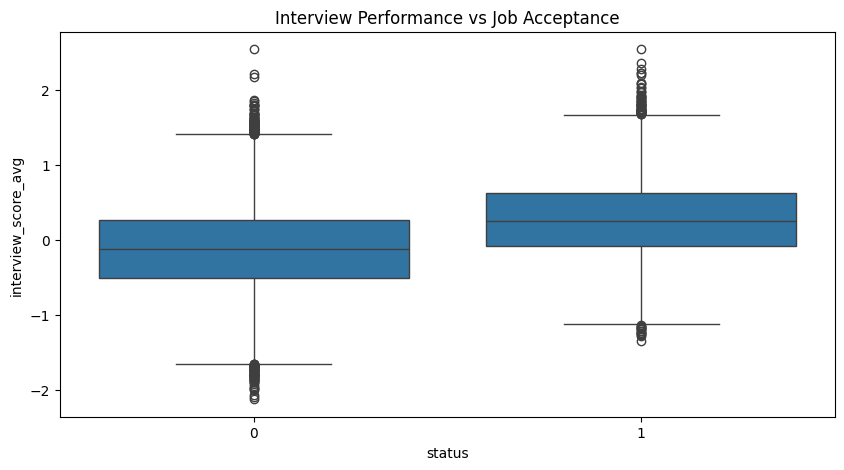

In [11]:
# 4. Interview Performance vs Acceptance

# Create interview average score for analysis
df['interview_score_avg'] = (
    df['technical_score'] +
    df['aptitude_score'] +
    df['communication_score']
) / 3

plt.figure(figsize=(10,5))
sns.boxplot(x='status', y='interview_score_avg', data = df)
plt.title('Interview Performance vs Job Acceptance')
plt.show() 

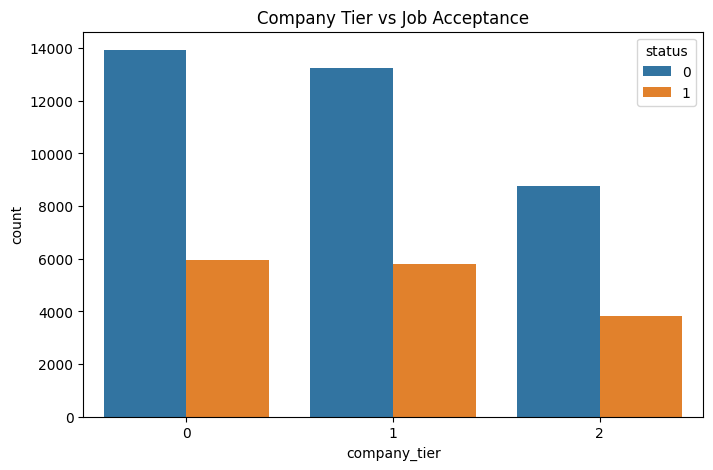

In [12]:
# 5. Company Tier vs Acceptance Rate
plt.figure(figsize=(8,5))
sns.countplot(x='company_tier', hue='status', data=df)
plt.title('Company Tier vs Job Acceptance')
plt.show() 

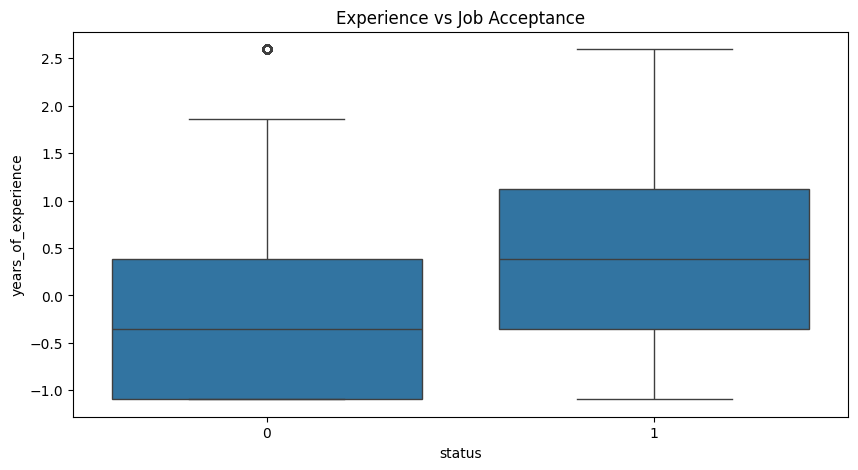

In [13]:
# 6. Experience Vs Placement Probability
plt.figure(figsize=(10,5))
sns.boxplot(x='status', y='years_of_experience', data=df)
plt.title('Experience vs Job Acceptance')
plt.show() 

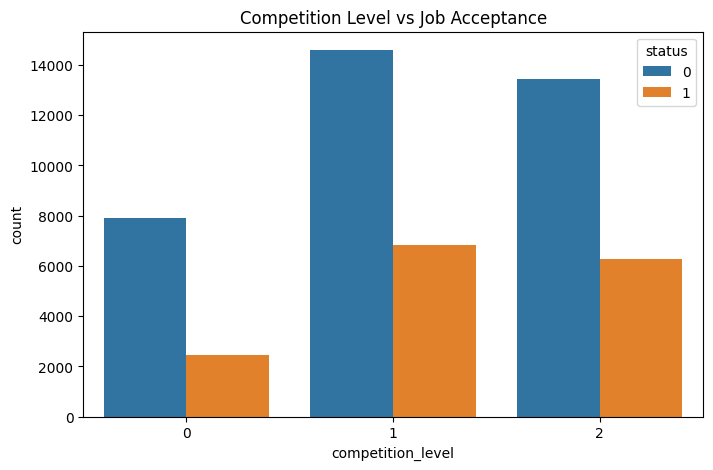

In [14]:
# 7. Competition Level Impact
plt.figure(figsize=(8,5))
sns.countplot(x='competition_level', hue='status', data=df)
plt.title('Competition Level vs Job Acceptance')
plt.show() 

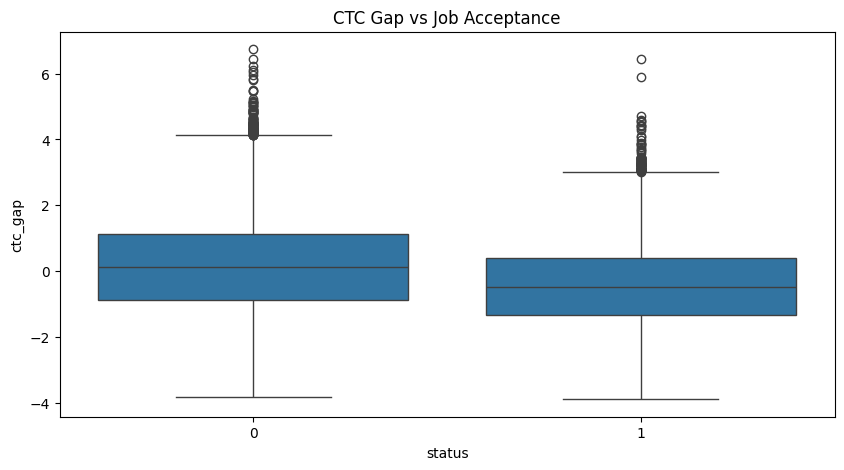

In [15]:
# 8. Compensation Gap Analysis
df['ctc_gap'] = df['expected_ctc_lpa'] - df['previous_ctc_lpa']

plt.figure(figsize=(10,5))
sns.boxplot(x='status', y='ctc_gap', data=df)
plt.title('CTC Gap vs Job Acceptance')
plt.show() 

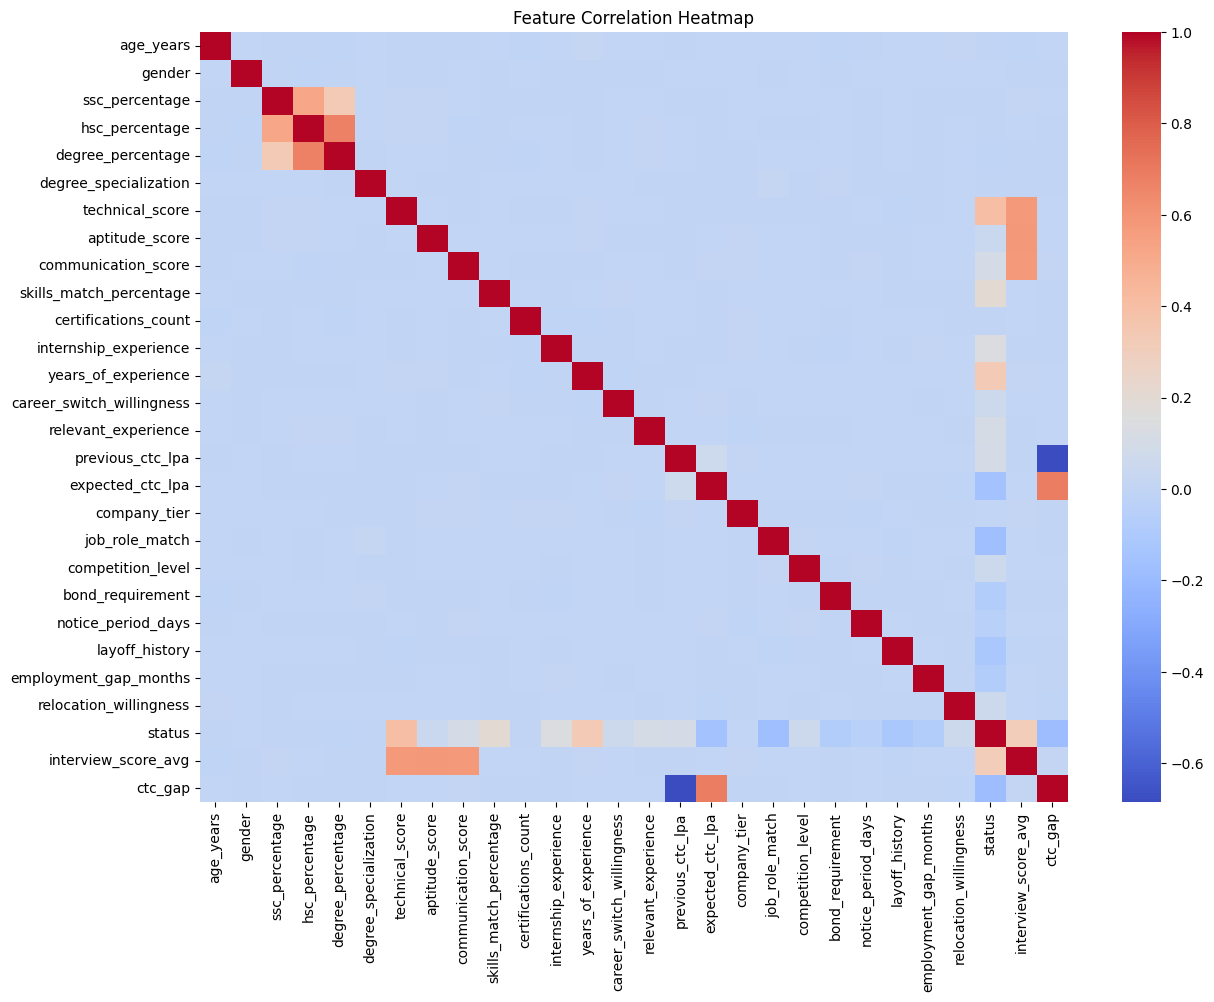

In [16]:
# 9. Correlation Analysis (Numeric Features)
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), cmap='coolwarm', annot=False)
plt.title('Feature Correlation Heatmap')
plt.show() 

In [ ]:
# Hypothesis Testing 
# Does skills match significantly affect job acceptance?
# H₀ (Null): Skills match has no effect
# H₁ (Alt): Skills match affects job acceptance

from scipy.stats import ttest_ind

placed = df[df['status']==1]['skills_match_percentage']
not_placed = df[df['status']==0]['skills_match_percentage']

t_stat, p_val = ttest_ind(placed, not_placed)

print("T-statistic:", t_stat)
print("P-value:", p_val) 

T-statistic: 45.805068238462866
P-value: 0.0


In [18]:
# Chi-Square Test (Categorical vs Categorical)
# Company tier vs job acceptance
from scipy.stats import chi2_contingency

contingency = pd.crosstab(df['company_tier'], df['status'])
chi2, p, dof, expected = chi2_contingency(contingency)

print("Chi-square:", chi2)
print("P-value:", p) 

Chi-square: 1.4098464639959754
P-value: 0.4941465074401733
